# T2 Data access and profiling

In [1]:
import os
os.environ["AWS_PROFILE"] = "javier-whizdom-prod-ds"

import boto3
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BUCKET = "whizdomai-eu-central-1-650177547431-datalake-gmntc-prod"


def s3_duckdb():
    """DuckDB connection with the credentials of the SSO profile already loaded."""
    creds = boto3.Session(profile_name="javier-whizdom-prod-ds").get_credentials().get_frozen_credentials()
    con = duckdb.connect()
    con.sql("INSTALL httpfs; LOAD httpfs;")

    con.sql("SET memory_limit='4GB'")
    con.sql("SET threads=2")
    con.sql(f"""
        CREATE OR REPLACE SECRET s3_secret (
            TYPE S3, KEY_ID '{creds.access_key}', SECRET '{creds.secret_key}',
            SESSION_TOKEN '{creds.token}', REGION 'eu-central-1'
        );
    """)
    return con

## Read access: operator tables in the `10-landing` layer (kafka-sink)

We checked access on 2026-09-10, to `s3://whizdomai-eu-central-1-650177547431-datalake-gmntc-prod/org/10-landing/kafka-sink/`.

There are two operators. Each one has the same five tables: `primus/` and `secundus/`.

| Business table | Real S3 prefix | Why we chose this mapping |
|---|---|---|
| `player` | `whizdomai-players` | Profile and registration columns: `firstname`, `birthdate`, `regdate`, `kycStatus`. |
| `bet` | `whizdomai-transactions` | The prefix name sounds like money transactions, but it has `gameId`, `gameTranId`, `tranType`, `amountReal` and `balanceReal`. This is the game and betting ledger. |
| `transaction` | `whizdomai-payments` | The prefix name sounds like generic payments, but it has `requestedAmount`, `fee`, `accountNumber` and `transactionMethod`. This is deposits and withdrawals. |
| `bonus` | `whizdomai-bonuses` | Columns about bonus exposure per player: `triggerDate`, `wagerRequirement`, `releasedBonus`. |
| `session` | Does not exist | There is no session or login prefix under `10-landing/kafka-sink`, for `primus` or `secundus`. We also checked the gold layer, and it is not there either. |


In [2]:
LANDING_LEVEL = "org/10-landing/kafka-sink"
OPERATORS = ["primus", "secundus"]


LANDING_TABLES = {
    "player": "whizdomai-players",
    "bet": "whizdomai-transactions",
    "transaction": "whizdomai-payments",
    "bonus": "whizdomai-bonuses",
}

SNAPSHOT_DAY = ("2026", "09", "10")


def run_landing_query(query, tables, operator, year="*", month="*", day="*"):
    """Run a query on S3 landing Parquet files. Do not download any file to disk.

    Args:
        query (str): The SQL query to run.
        tables (list[str]): List of landing table prefixes, e.g. ["whizdomai-players"].
        operator (str): "primus" or "secundus".
        year (str, optional): Year partition. Use "*" for all years. Default is "*".
        month (str, optional): Month partition. Use "*" for all months. Default is "*".
        day (str, optional): Day partition. Use "*" for all days. Default is "*".

    Returns:
        pd.DataFrame: The query result.

    Note:
        Landing is the raw Kafka-Connect S3 sink. The Gold layer stores each day
        in one file, `data.parquet`. Landing is different: it has many small
        `*.snappy.parquet` files per day, one for each hour. So we need a glob
        pattern (`*`) to read them all.
    """
    con = s3_duckdb()
    for t in tables:
        path = f"s3://{BUCKET}/{LANDING_LEVEL}/{operator}/{t}/{year}/{month}/{day}/*.snappy.parquet"
        view = t.replace("-", "_")
        con.sql(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM read_parquet('{path}', union_by_name=True)")
    result = con.sql(query).df()
    con.close()
    return result

Access check: one `COUNT` per table and operator, for the snapshot day. We do not load any rows into memory.

In [3]:
access_check = []
for operator in OPERATORS:
    for business_name, landing_table in LANDING_TABLES.items():
        view = landing_table.replace("-", "_")
        try:
            n_rows = run_landing_query(
                f"SELECT count(*) AS n FROM {view}",
                tables=[landing_table], operator=operator,
                year=SNAPSHOT_DAY[0], month=SNAPSHOT_DAY[1], day=SNAPSHOT_DAY[2],
            )["n"].iloc[0]
            access_check.append((operator, business_name, landing_table, "OK", n_rows))
        except Exception as e:
            access_check.append((operator, business_name, landing_table, f"FAIL: {e}", None))

access_check = pd.DataFrame(access_check, columns=["operator", "business_table", "landing_table", "status", "rows"])
access_check

,operator,business_table,landing_table,status,rows
0,primus,player,whizdomai-players,OK,13493
1,primus,bet,whizdomai-transactions,OK,13872583
2,primus,transaction,whizdomai-payments,OK,84570
3,primus,bonus,whizdomai-bonuses,OK,60353
4,secundus,player,whizdomai-players,OK,11326
5,secundus,bet,whizdomai-transactions,OK,8508825
6,secundus,transaction,whizdomai-payments,OK,49330
7,secundus,bonus,whizdomai-bonuses,OK,48660


**Result.** We confirmed read access for all 8 table × operator combinations (4 tables, 2 operators). `session` is not in this list because it does not exist as a table in this layer (see the section above).

## Data quality: `10-landing` layer

Every calculation runs in DuckDB, over 100% of the rows in the chosen period. `COUNT`, `glob` and `SUMMARIZE` scan all the data in streaming mode, and only send the summary back to pandas.

We split the profiling into two time periods. The cost of each check decides the period:

- **Date range and gaps** (`HISTORY_START`–`HISTORY_END`): covers all available history, from `2026-06-18` to `2026-09-29`. This check is cheap: `glob()` only lists the files for each day, it does not read them (about 0.3–0.7 seconds per day, no matter the table size). This lets us cover about four months, four tables and two operators in a few minutes.
- **Nulls, row count and grain signal** (`QUALITY_START`–`QUALITY_END`): uses a default 7-day window (`2026-09-23` to `2026-09-29`). This check is more expensive, because `SUMMARIZE` reads every column. For `bet` (`whizdomai-transactions`) it took about 162 seconds per operator, per day scanned. We could widen this window to the full history, but for `bet` alone that would take several hours.


In [4]:
import datetime as dt

GRAIN_CANDIDATE_KEYS = {
    "player": ["uuid", "partyId"],
    "bet": ["transactionId", "partyId"],
    "transaction": ["paymentId", "partyId"],
    "bonus": ["changeId", "id", "partyId"],
}


HISTORY_START = dt.date(2026, 6, 18)
HISTORY_END = dt.date(2026, 9, 29)
HISTORY_DAYS = [HISTORY_START + dt.timedelta(days=i) for i in range((HISTORY_END - HISTORY_START).days + 1)]


QUALITY_START = dt.date(2026, 9, 23)
QUALITY_END = dt.date(2026, 9, 29)
QUALITY_DAYS = [QUALITY_START + dt.timedelta(days=i) for i in range((QUALITY_END - QUALITY_START).days + 1)]


def landing_paths(operator, landing_table, days):
    return [
        f"s3://{BUCKET}/{LANDING_LEVEL}/{operator}/{landing_table}/{d.year}/{d.month:02d}/{d.day:02d}/*.snappy.parquet"
        for d in days
    ]


def daily_presence(business_name, operator, days):
    """Check, for each day, if any file exists in S3. Do not read the file content.

    This is a light check. It only lists file names with `glob()`. It does not
    open or read the files. We use it to find the real date range, and to
    find gap days (days with no data).

    Args:
        business_name (str): Business table name, e.g. "player".
        operator (str): "primus" or "secundus".
        days (list[date]): List of days to check.

    Returns:
        list[dict]: One row per day, with the operator, table name, date, and file count.

    Note:
        Each check takes about 0.3-0.7 seconds per day. Table size does not
        matter, because we only list files, we never read them. This makes it
        cheap enough to run over the full history. A day with 0 files can
        mean two things: a real gap, or a day outside the table's real
        range. The code that calls this function decides which one it is.
    """
    landing_table = LANDING_TABLES[business_name]
    con = s3_duckdb()
    rows = []
    for d in days:
        path = f"s3://{BUCKET}/{LANDING_LEVEL}/{operator}/{landing_table}/{d.year}/{d.month:02d}/{d.day:02d}/*.snappy.parquet"
        n_files = con.sql(f"SELECT count(*) FROM glob('{path}')").fetchone()[0]
        rows.append({"operator": operator, "business_table": business_name, "date": d, "n_files": n_files})
    con.close()
    return rows


def column_profile(business_name, operator, days):
    """Run `SUMMARIZE` over every row in `days`. One pass, no sampling.

    This gives the exact row count and the exact null % for each column. It
    also gives an approximate count of unique values per column (using
    HyperLogLog). We use that approximate count as a signal for the table's grain.
    """
    landing_table = LANDING_TABLES[business_name]
    view = landing_table.replace("-", "_")
    paths = landing_paths(operator, landing_table, days)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    summary = con.sql(f"SUMMARIZE SELECT * FROM {view}").df()
    con.close()
    summary.insert(0, "operator", operator)
    summary.insert(1, "business_table", business_name)
    return summary

### Primary key uniqueness (grain)

In [5]:
exact_grain_rows = []
for operator in OPERATORS:
    for business_name, keys in GRAIN_CANDIDATE_KEYS.items():
        landing_table = LANDING_TABLES[business_name]
        view = landing_table.replace("-", "_")
        distinct_exprs = ", ".join(f'count(DISTINCT "{k}") AS n_{k}' for k in keys)
        result = run_landing_query(
            f"SELECT count(*) AS n_rows, {distinct_exprs} FROM {view}",
            tables=[landing_table], operator=operator,
            year=SNAPSHOT_DAY[0], month=SNAPSHOT_DAY[1], day=SNAPSHOT_DAY[2],
        )
        for k in keys:
            exact_grain_rows.append({
                "operator": operator,
                "business_table": business_name,
                "column_name": k,
                "n_distinct": int(result[f"n_{k}"].iloc[0]),
                "n_rows": int(result["n_rows"].iloc[0]),
            })

exact_grain_check = pd.DataFrame(exact_grain_rows)
exact_grain_check["uniqueness_ratio"] = (exact_grain_check["n_distinct"] / exact_grain_check["n_rows"]).round(4)
exact_grain_check = exact_grain_check.sort_values(
    ["business_table", "operator", "uniqueness_ratio"], ascending=[True, True, False]
)
print(f"Exact grain check for {SNAPSHOT_DAY[0]}-{SNAPSHOT_DAY[1]}-{SNAPSHOT_DAY[2]}")
exact_grain_check

Exact grain check for 2026-09-10


,operator,business_table,column_name,n_distinct,n_rows,uniqueness_ratio
2,primus,bet,transactionId,13872583,13872583,1.0000
3,primus,bet,partyId,16862,13872583,0.0012
11,secundus,bet,transactionId,8508825,8508825,1.0000
12,secundus,bet,partyId,11401,8508825,0.0013
6,primus,bonus,changeId,60353,60353,1.0000
7,primus,bonus,id,28713,60353,0.4758
8,primus,bonus,partyId,12548,60353,0.2079
15,secundus,bonus,changeId,48660,48660,1.0000
16,secundus,bonus,id,22972,48660,0.4721
17,secundus,bonus,partyId,9755,48660,0.2005


| Business table | Grain | Key that proves it |
|---|---|---|
| `player` | One row per player change event. The key is `partyId`, and it repeats. `uuid` does not identify the player — it identifies the event itself, and it is 100% unique. | `uuid` unique, `partyId` repeats |
| `bet` | One row per bet or transaction. The key is `transactionId`, 100% unique. | `transactionId` unique |
| `transaction` (`whizdomai-payments`) | One row per payment status change, not one row per payment. `paymentId` repeats. | `paymentId` repeats |
| `bonus` | One row per bonus status-change event. The key is `changeId`, 100% unique. `id` identifies the bonus itself, and it repeats. | `changeId` unique, `id` repeats |

**Result.** Each table has one key that is 100% unique, and this is the same in both operators: `player.uuid`, `bet.transactionId`, `bonus.changeId`. No candidate key in `transaction` (`whizdomai-payments`) is unique: `paymentId` only identifies about 58% of the rows in both operators (ratio 0.58–0.59). This confirms that the table stores payment status-change events, not one row per payment.

### Date range and gaps

In [6]:
presence_rows = []
for operator in OPERATORS:
    for business_name in LANDING_TABLES:
        presence_rows += daily_presence(business_name, operator, HISTORY_DAYS)

presence = pd.DataFrame(presence_rows)
presence["has_data"] = presence["n_files"] > 0

summary_rows = []
for (operator, business_name), grp in presence.groupby(["operator", "business_table"]):
    with_data = grp[grp["has_data"]]
    if with_data.empty:
        summary_rows.append({"operator": operator, "business_table": business_name,
                              "date_min": None, "date_max": None, "n_days_with_data": 0,
                              "n_gap_days": None, "gap_dates": []})
        continue
    date_min, date_max = with_data["date"].min(), with_data["date"].max()

    within_range = grp[(grp["date"] >= date_min) & (grp["date"] <= date_max)]
    gaps = sorted(within_range.loc[~within_range["has_data"], "date"].tolist())
    summary_rows.append({
        "operator": operator, "business_table": business_name,
        "date_min": date_min, "date_max": date_max,
        "n_days_with_data": int(with_data.shape[0]),
        "n_gap_days": len(gaps), "gap_dates": gaps,
    })

date_range_gaps = pd.DataFrame(summary_rows)
date_range_gaps

,operator,business_table,date_min,date_max,n_days_with_data,n_gap_days,gap_dates
0,primus,bet,2026-06-18,2026-09-29,104,0,[]
1,primus,bonus,2026-06-18,2026-09-29,104,0,[]
2,primus,player,2026-06-18,2026-09-29,104,0,[]
3,primus,transaction,2026-06-18,2026-09-29,104,0,[]
4,secundus,bet,2026-06-18,2026-09-29,104,0,[]
5,secundus,bonus,2026-06-18,2026-09-29,104,0,[]
6,secundus,player,2026-06-18,2026-09-29,104,0,[]
7,secundus,transaction,2026-06-18,2026-09-29,104,0,[]


**Result.** 0 gaps in all 8 table × operator combinations, over 104 days of available history (`2026-06-18` to `2026-09-29`). All 4 tables start and end on the same day, in both operators.

### Nulls, row count and approximate grain

In [7]:
from IPython.display import display


column_profiles = {}
for operator in OPERATORS:
    for business_name in LANDING_TABLES:
        column_profiles[(operator, business_name)] = column_profile(business_name, operator, QUALITY_DAYS)

all_profiles = pd.concat(column_profiles.values(), ignore_index=True)

row_counts = (
    all_profiles.groupby(["operator", "business_table"])["count"]
    .first()
    .rename("n_rows_in_window")
    .reset_index()
)

null_summary = all_profiles[all_profiles["null_percentage"] > 0][
    ["operator", "business_table", "column_name", "null_percentage"]
].sort_values("null_percentage", ascending=False)

candidate_cols = {k for keys in GRAIN_CANDIDATE_KEYS.values() for k in keys}
grain_check = all_profiles[all_profiles["column_name"].isin(candidate_cols)][
    ["operator", "business_table", "column_name", "approx_unique", "count"]
].copy()
grain_check["uniqueness_ratio"] = (grain_check["approx_unique"] / grain_check["count"]).round(3)
grain_check = grain_check.sort_values(["business_table", "operator", "uniqueness_ratio"], ascending=[True, True, False])

print(f"Quality window: {QUALITY_START} to {QUALITY_END}")
display(row_counts)
display(null_summary)
display(grain_check)

Quality window: 2026-09-23 to 2026-09-29


,operator,business_table,n_rows_in_window
0,primus,bet,99516079
1,primus,bonus,417344
2,primus,player,98794
3,primus,transaction,512679
4,secundus,bet,55087773
5,secundus,bonus,290296
6,secundus,player,95316
7,secundus,transaction,311255


,operator,business_table,column_name,null_percentage
122,secundus,player,unit,100.00
23,primus,player,birthCity,100.00
22,primus,player,birthCountry,99.99
29,primus,player,iban,99.99
137,secundus,player,lastKycRequestedDate,99.99
...,...,...,...,...
67,primus,bet,platformTranId,0.05
172,secundus,bet,gameTranId,0.05
68,primus,bet,gameTranId,0.02
69,primus,bet,gameId,0.02


,operator,business_table,column_name,approx_unique,count,uniqueness_ratio
41,primus,bet,transactionId,118474865,99516079,1.191
40,primus,bet,uuid,91669967,99516079,0.921
44,primus,bet,partyId,50955,99516079,0.001
144,secundus,bet,uuid,68103210,55087773,1.236
145,secundus,bet,transactionId,51196100,55087773,0.929
148,secundus,bet,partyId,24998,55087773,0.000
86,primus,bonus,changeId,366386,417344,0.878
88,primus,bonus,id,173849,417344,0.417
89,primus,bonus,partyId,53847,417344,0.129
190,secundus,bonus,changeId,280981,290296,0.968


### Schema

This reuses the `SUMMARIZE` result from the cell above (same 7-day window): column name, type and null % for each table. Before we list it, we compare the set of columns and types between `primus` and `secundus`, to check there is no structural difference between operators.

In [8]:
from IPython.display import display

mismatched = [
    business_name for business_name in LANDING_TABLES
    if set(zip(
        all_profiles.loc[(all_profiles.business_table == business_name) & (all_profiles.operator == OPERATORS[0]), "column_name"],
        all_profiles.loc[(all_profiles.business_table == business_name) & (all_profiles.operator == OPERATORS[0]), "column_type"],
    )) != set(zip(
        all_profiles.loc[(all_profiles.business_table == business_name) & (all_profiles.operator == OPERATORS[1]), "column_name"],
        all_profiles.loc[(all_profiles.business_table == business_name) & (all_profiles.operator == OPERATORS[1]), "column_type"],
    ))
]
print("Schema differs between operators in:", mismatched or "no tables")

for business_name in LANDING_TABLES:
    print(f"\n--- {business_name} ---")
    display(
        all_profiles[(all_profiles.business_table == business_name) & (all_profiles.operator == OPERATORS[0])]
        [["column_name", "column_type", "null_percentage"]]
        .sort_values("column_name")
        .reset_index(drop=True)
    )

Schema differs between operators in: no tables

--- player ---


,column_name,column_type,null_percentage
0,address,VARCHAR,65.16
1,birthCity,VARCHAR,100.00
2,birthCountry,VARCHAR,99.99
3,birthdate,TIMESTAMP WITH TIME ZONE,15.98
4,brandId,INTEGER,0.00
5,building,VARCHAR,99.86
6,city,VARCHAR,65.18
7,country,VARCHAR,0.32
8,currency,VARCHAR,0.00
9,documentNumber,VARCHAR,96.79



--- bet ---


,column_name,column_type,null_percentage
0,accountId,INTEGER,0.00
1,address,VARCHAR,7.04
2,amountPlayableBonus,"DECIMAL(38,18)",0.00
3,amountRawLoyalty,BIGINT,0.00
4,amountReal,"DECIMAL(38,18)",0.00
5,amountReleasedBonus,"DECIMAL(38,18)",0.00
6,balancePlayableBonus,"DECIMAL(38,18)",0.00
7,balanceRawLoyalty,BIGINT,0.00
8,balanceReal,"DECIMAL(38,18)",0.00
9,balanceReleasedBonus,"DECIMAL(38,18)",0.00



--- transaction ---


,column_name,column_type,null_percentage
0,accountNumber,INTEGER,0.00
1,brandId,INTEGER,0.00
2,currency,VARCHAR,0.00
3,fee,"DECIMAL(38,18)",0.00
4,partyId,INTEGER,0.00
5,paymentId,INTEGER,0.00
6,processDate,TIMESTAMP WITH TIME ZONE,57.96
7,processedAmount,"DECIMAL(38,18)",0.00
8,requestDate,TIMESTAMP WITH TIME ZONE,0.00
9,requestedAmount,"DECIMAL(38,18)",98.39



--- bonus ---


,column_name,column_type,null_percentage
0,amount,"DECIMAL(38,18)",0.00
1,amountWagered,"DECIMAL(38,18)",0.00
2,bonusPlanId,INTEGER,0.00
3,changeId,BIGINT,0.00
4,changeStatusTimestamp,TIMESTAMP WITH TIME ZONE,0.00
5,expiryDate,TIMESTAMP WITH TIME ZONE,0.00
6,id,INTEGER,0.00
7,partyId,INTEGER,0.00
8,playableBonus,"DECIMAL(38,18)",0.00
9,playableBonusWinnings,"DECIMAL(38,18)",0.00


## Choosing the session gap threshold

Before we pick a number for `SESSION_GAP_MINUTES`, we look at how long players actually wait between two consecutive bets. The method: bin the gap between every pair of consecutive bets from the same player, on a log scale, and look for a point where short, dense "still playing" gaps end and longer, sparser "came back later" gaps begin.

We compute this histogram in DuckDB, not in pandas.

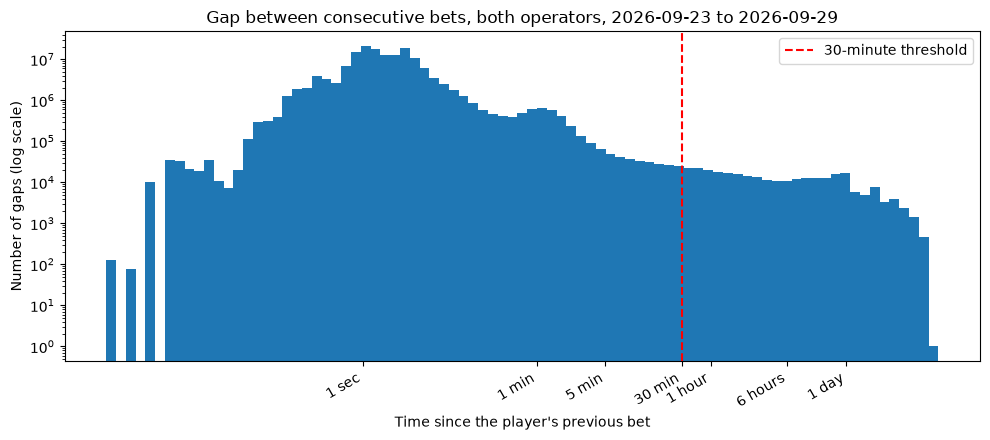

Total gaps: 154,525,292
Share of gaps shorter than 30 minutes: 99.81%


In [9]:
def bet_gap_histogram(operator, days):
    """Bin the time between consecutive bet events per player, on a log10(minutes) scale.

    This runs in DuckDB as a window function (LAG) plus a GROUP BY on the
    binned gap. Only around 80 histogram bins come back to Python -- there
    are close to 100M raw gaps per operator in this window, and we never
    load them one by one.
    """
    landing_table = LANDING_TABLES["bet"]
    view = landing_table.replace("-", "_")
    paths = landing_paths(operator, landing_table, days)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    query = f"""
        WITH events AS (
            SELECT partyId, dateTime
            FROM {view}
            WHERE partyId IS NOT NULL AND dateTime IS NOT NULL
        ),
        gaps AS (
            SELECT epoch(dateTime - LAG(dateTime) OVER (PARTITION BY partyId ORDER BY dateTime)) / 60.0 AS gap_minutes
            FROM events
        )
        SELECT floor(log10(gap_minutes) * 10) / 10 AS log10_min_bucket, count(*) AS n
        FROM gaps
        WHERE gap_minutes > 0
        GROUP BY 1
        ORDER BY 1
    """
    hist = con.sql(query).df()
    con.close()
    hist.insert(0, "operator", operator)
    return hist


gap_hist = pd.concat([bet_gap_histogram(operator, QUALITY_DAYS) for operator in OPERATORS], ignore_index=True)

gap_hist_combined = gap_hist.groupby("log10_min_bucket")["n"].sum().reset_index().sort_values("log10_min_bucket")
gap_hist_combined["minutes"] = 10 ** gap_hist_combined["log10_min_bucket"]
gap_hist_combined["pct"] = gap_hist_combined["n"] / gap_hist_combined["n"].sum() * 100

tick_minutes = [1 / 60, 1, 5, 30, 60, 60 * 6, 60 * 24]
tick_labels = ["1 sec", "1 min", "5 min", "30 min", "1 hour", "6 hours", "1 day"]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(gap_hist_combined["log10_min_bucket"], gap_hist_combined["n"], width=0.1, align="edge")
ax.set_yscale("log")
ax.set_xticks([np.log10(m) for m in tick_minutes])
ax.set_xticklabels(tick_labels, rotation=30, ha="right")
ax.axvline(np.log10(30), color="red", linestyle="--", label="30-minute threshold")
ax.set_xlabel("Time since the player's previous bet")
ax.set_ylabel("Number of gaps (log scale)")
ax.set_title(f"Gap between consecutive bets, both operators, {QUALITY_START} to {QUALITY_END}")
ax.legend()
plt.tight_layout()
plt.show()

pct_under_30 = gap_hist_combined.loc[gap_hist_combined["minutes"] <= 30, "pct"].sum()
print(f"Total gaps: {int(gap_hist_combined['n'].sum()):,}")
print(f"Share of gaps shorter than 30 minutes: {pct_under_30:.2f}%")

**Result.** 154,525,292 consecutive-bet gaps, both operators, 7-day window. The distribution does not have a sharp, clean valley, it declines smoothly from a large peak around 1–4 seconds (players placing bets back to back) all the way through minutes and hours, with no single obvious break point. **99.81% of all consecutive-bet gaps are shorter than 30 minutes**: the large majority of activity is rapid, back-to-back betting, and only a small, gradually-thinning tail represents real pauses. There is a small secondary bump around 17–21 hours, consistent with players who come back roughly once a day — an interesting signal on its own (possibly useful later as a "typical time of day" feature), but not directly about session boundaries.

Given there is no sharp elbow to point to, we keep `SESSION_GAP_MINUTES = 30`: it sits well past the dense "still playing" mass (99.8% of all gaps).

## Derived: session gaps from `bet`

There is no `session` table in this layer (see the access section above). We rebuild player sessions from `bet` event timestamps instead: a new session starts after a gap of at least `SESSION_GAP_MINUTES` minutes with no bet event for that player (30 minutes, justified with real data in the section above).

The whole calculation runs as SQL window functions in DuckDB (`LAG`, `LEAD`, `SUM() OVER`), not in pandas. Loading raw `partyId` + `dateTime` for all of `bet` is still too large (2 days of `primus` alone is close to 28M rows), so only the final session-gap rows come back to pandas a small result.

This uses the same `QUALITY_DAYS` window as the section above (`2026-09-23` to `2026-09-29`) due to the computational cost. 

In [10]:
def session_gaps(operator, days, gap_minutes=30):
    """Rebuild player sessions from bet events, and return the gap before the next session, in hours.

    We split bet events into sessions per player: a new session starts after
    a stretch of at least `gap_minutes` with no bet event. All of this runs
    as SQL window functions in DuckDB (LAG/LEAD/SUM OVER), not in pandas --
    only the final session-gap rows come back to Python.

    Args:
        operator (str): "primus" or "secundus".
        days (list[date]): List of days to scan.
        gap_minutes (int, optional): Minutes of silence that start a new session. Default is 30.

    Returns:
        pd.DataFrame: One row per gap between two sessions of the same player:
            `operator`, `partyId`, `session_start`, `session_end` (of the
            earlier session), `gap_hours` (time until the next session
            starts). The last session of each player has no "next" session
            in the window, so it does not appear here.
    """
    landing_table = LANDING_TABLES["bet"]
    view = landing_table.replace("-", "_")
    paths = landing_paths(operator, landing_table, days)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    query = f"""
        WITH events AS (
            SELECT partyId, dateTime
            FROM {view}
            WHERE partyId IS NOT NULL AND dateTime IS NOT NULL
        ),
        with_gap AS (
            SELECT partyId, dateTime,
                   dateTime - LAG(dateTime) OVER (PARTITION BY partyId ORDER BY dateTime) AS gap
            FROM events
        ),
        with_flag AS (
            SELECT partyId, dateTime,
                   CASE WHEN gap IS NULL OR gap > INTERVAL '{gap_minutes} minutes' THEN 1 ELSE 0 END AS new_session
            FROM with_gap
        ),
        with_session_id AS (
            SELECT partyId, dateTime,
                   SUM(new_session) OVER (PARTITION BY partyId ORDER BY dateTime
                                           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS session_id
            FROM with_flag
        ),
        sessions AS (
            SELECT partyId, session_id, MIN(dateTime) AS session_start, MAX(dateTime) AS session_end
            FROM with_session_id
            GROUP BY partyId, session_id
        ),
        with_next AS (
            SELECT partyId, session_start, session_end,
                   LEAD(session_start) OVER (PARTITION BY partyId ORDER BY session_start) AS next_session_start
            FROM sessions
        )
        SELECT partyId, session_start, session_end,
               epoch(next_session_start - session_end) / 3600.0 AS gap_hours
        FROM with_next
        WHERE next_session_start IS NOT NULL
        ORDER BY partyId, session_start
    """
    result = con.sql(query).df()
    con.close()
    result.insert(0, "operator", operator)
    return result


SESSION_GAP_MINUTES = 30

session_gap_frames = [session_gaps(operator, QUALITY_DAYS, SESSION_GAP_MINUTES) for operator in OPERATORS]
session_gaps_df = pd.concat(session_gap_frames, ignore_index=True)

print(f"Session gap window: {QUALITY_START} to {QUALITY_END}, {SESSION_GAP_MINUTES}-minute gap threshold")
print(f"rows: {len(session_gaps_df)}, distinct partyId: {session_gaps_df['partyId'].nunique()}")
session_gaps_df.groupby("operator")["gap_hours"].describe()

RuntimeError: Query interrupted

**Result.** 7-day window, `SESSION_GAP_MINUTES = 30`: 295,307 session gaps across 45,764 distinct players. The typical gap between two sessions is a few hours. The smallest gap in the whole result is just above 30 minutes (0.50000278h), confirming the threshold boundary works as intended nothing shorter than `SESSION_GAP_MINUTES` can appear as a gap, by definition. The largest gap is close to 167 hours, just under the 7-day window itself, as expected.

Running both operators takes about 18 minutes total (`primus`: 680s, `secundus`: 410s) this is the slowest cell in the notebook. Unlike `SUMMARIZE` or the exact grain check, this one has to scan and sort every single `bet` row per player, not just aggregate columns.

## Summary: shape of the data

Built from the DataFrames we already computed above (`exact_grain_check`, `date_range_gaps`, `row_counts`, `null_summary`). This does not touch S3 again.

In [ ]:
summary_rows = []
for business_name in LANDING_TABLES:
    pk_per_op = (
        exact_grain_check[exact_grain_check.business_table == business_name]
        .groupby("column_name")["uniqueness_ratio"].min()
    )
    pk_cols = pk_per_op[pk_per_op == 1.0].index.tolist()

    dr = date_range_gaps[date_range_gaps.business_table == business_name]
    date_min, date_max = dr["date_min"].min(), dr["date_max"].max()
    n_gaps = int(dr["n_gap_days"].sum())

    total_rows_window = int(row_counts[row_counts.business_table == business_name]["n_rows_in_window"].sum())

    top_nulls = (
        null_summary[null_summary.business_table == business_name]
        .groupby("column_name")["null_percentage"].max()
        .sort_values(ascending=False)
        .head(3)
    )
    top_nulls_str = ", ".join(f"{name} ({pct:.1f}%)" for name, pct in top_nulls.items()) or "no relevant nulls"

    summary_rows.append({
        "table": business_name,
        "primary key": ", ".join(pk_cols) if pk_cols else "no candidate key is 100% unique",
        "date range": f"{date_min} to {date_max}",
        "gap days": n_gaps,
        "rows (7d window, 2 operators)": total_rows_window,
        "columns with most nulls": top_nulls_str,
    })

data_shape_summary = pd.DataFrame(summary_rows)
data_shape_summary